In [1]:
import matplotlib.pyplot as plt
from price.shared import get_prices_by_ram_type
from datetime import date
from price.data import load_all_data
from datetime import date

[GenericData(title='Corsair Vengeance Black DDR3 PC12800 1600MHz 16GB (2x8GB) 9-9-9-24 - CMZ16GX3M2A1600C9', price='1415000', detail=None), GenericData(title='Team Elite Plus Black DDR4 PC19200 2400MHz 16GB (1x16GB) 16-16-16-39 - TPD416G2400HC1601', price='2650000', detail=None), GenericData(title='Team Elite Plus Black DDR4 PC19200 2400MHz 8GB (1x8GB) 16-16-16-39 - TPD48G2400HC1601', price='1060000', detail=None), GenericData(title='Team Elite Plus Black DDR4 PC19200 2400MHz 4GB (1x4GB) 16-16-16-39 - TPD44G2400HC1601', price='540000', detail=None), GenericData(title='VenomRX DDR3 PC12800 4GB', price='180000', detail=None), GenericData(title='VenomRX DDR3 PC12800 8GB', price='355000', detail=None), GenericData(title='V-GeN Platinum DDR3 2GB PC10600/PC12800', price='175000', detail=None), GenericData(title='V-GeN Platinum DDR3 4GB PC10600/PC12800 - Low Voltage', price='305000', detail=None), GenericData(title='V-GeN Platinum DDR3 8GB PC10600/PC12800 - Low Voltage', price='590000', detai

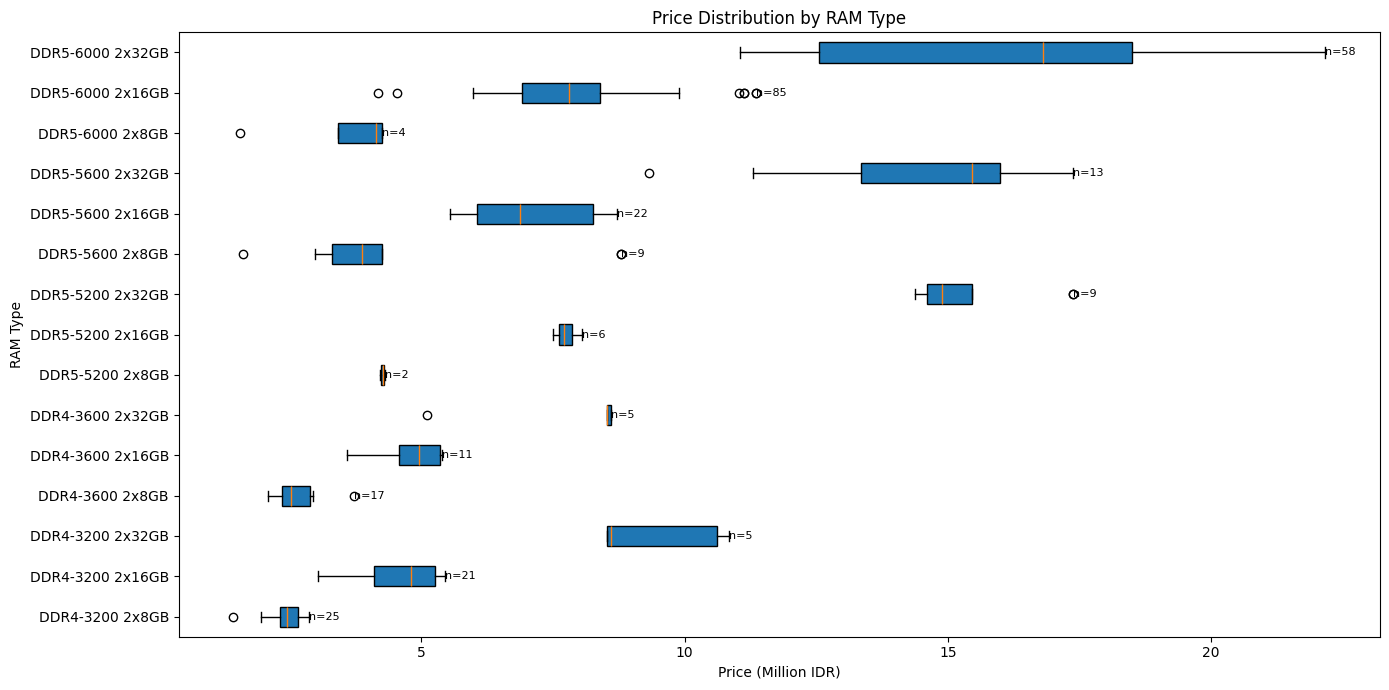

In [3]:
from price.shared import ProductCategory, ProductInfo, result_to_product_info
import re

prods = load_all_data(date.today())[ProductCategory.RAM]
prodinfos = map(lambda x: result_to_product_info(x.title + " " + (x.detail or ""), ProductCategory.RAM, int(x.price)), prods)
infos: list[ProductInfo] = list(filter(lambda x: x is not None, prodinfos)) # type: ignore

print(prods)

prices_by_type = get_prices_by_ram_type(infos)

def ram_sort_key(t):
    m = re.match(r'DDR(\d)-(\d+) (\d+)x(\d+)GB', t.value)
    gen, speed, count, size = int(m[1]), int(m[2]), int(m[3]), int(m[4])
    total = count * size
    return (gen, speed, total)

sorted_types = sorted(prices_by_type.keys(), key=ram_sort_key)
labels = [t.value for t in sorted_types]
box_data = [prices_by_type[t] for t in sorted_types]

box_data = [[p / 1e6 for p in prices] for prices in box_data]

print(labels, box_data)
fig, ax = plt.subplots(figsize=(14, 7))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("RAM Type")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by RAM Type")

for i, t in enumerate(sorted_types):
    ax.annotate(
        f"n={len(prices_by_type[t])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

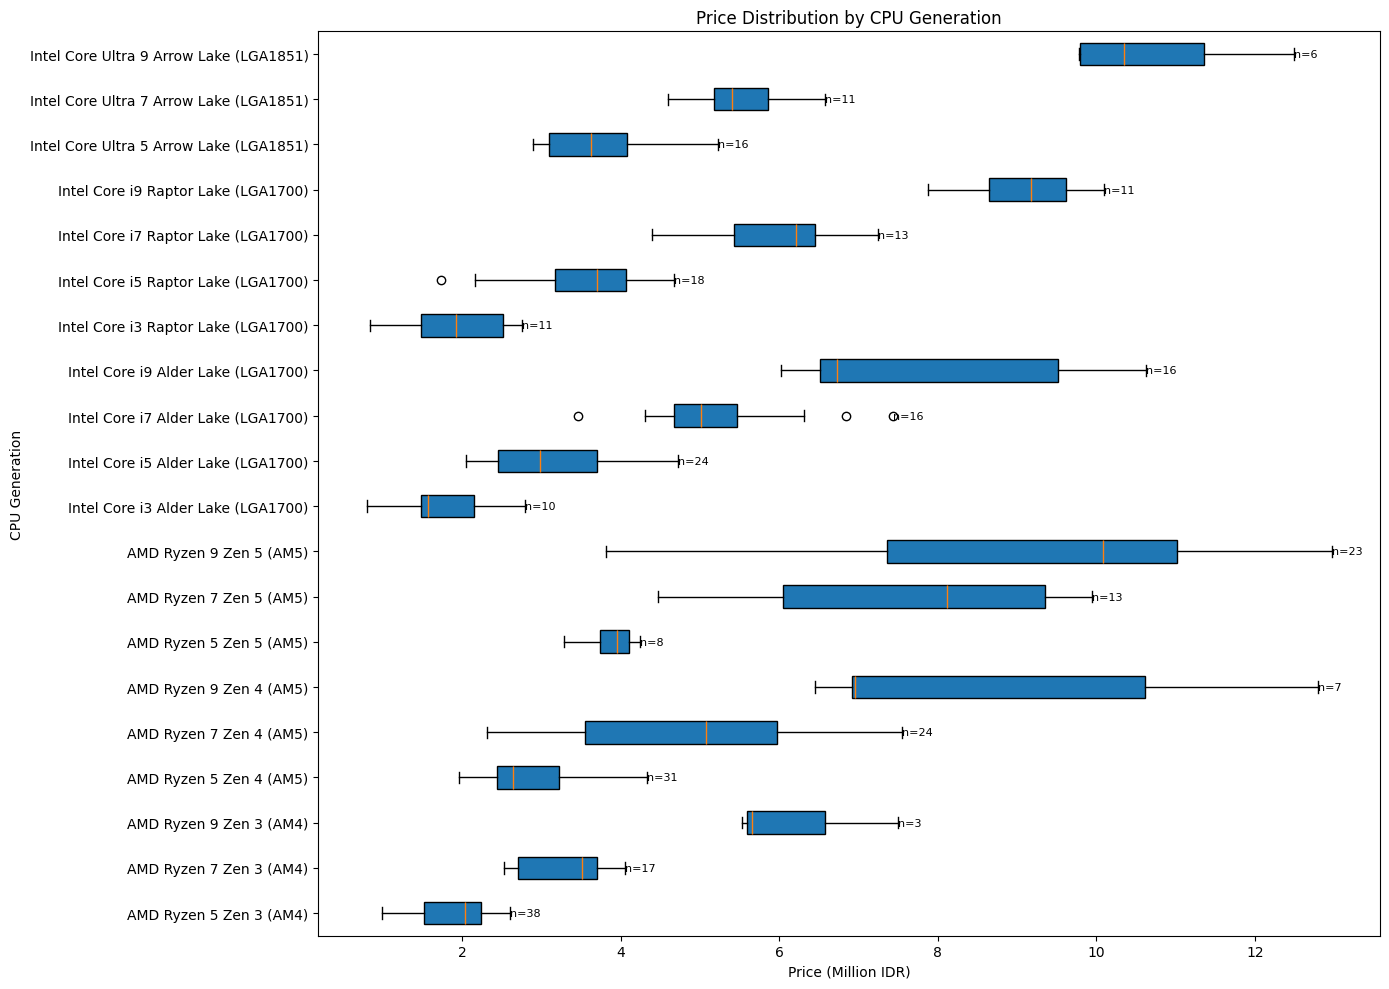

In [4]:
from collections import defaultdict
from price.shared import (
    ProductCategory, ProductInfo, result_to_product_info,
    CPUGeneration, CPUInfo, Brand
)
import re

prods = load_all_data(date.today())[ProductCategory.PROCESSOR]

def get_cpu_tier(title):
    if re.search(r'Core Ultra 9', title, re.IGNORECASE):
        return 'Core Ultra 9'
    if re.search(r'Core Ultra 7', title, re.IGNORECASE):
        return 'Core Ultra 7'
    if re.search(r'Core Ultra 5', title, re.IGNORECASE):
        return 'Core Ultra 5'
    if re.search(r'Ryzen 9', title, re.IGNORECASE):
        return 'Ryzen 9'
    if re.search(r'Ryzen 7', title, re.IGNORECASE):
        return 'Ryzen 7'
    if re.search(r'Ryzen 5', title, re.IGNORECASE):
        return 'Ryzen 5'
    if re.search(r'i9[- ]', title) or re.search(r'Core i9', title, re.IGNORECASE):
        return 'Core i9'
    if re.search(r'i7[- ]', title) or re.search(r'Core i7', title, re.IGNORECASE):
        return 'Core i7'
    if re.search(r'i5[- ]', title) or re.search(r'Core i5', title, re.IGNORECASE):
        return 'Core i5'
    if re.search(r'i3[- ]', title) or re.search(r'Core i3', title, re.IGNORECASE):
        return 'Core i3'
    return None

GEN_LABELS = {
    CPUGeneration.AMD_AM4: "Zen 3 (AM4)",
    CPUGeneration.AMD_AM5_Zen4: "Zen 4 (AM5)",
    CPUGeneration.AMD_AM5_Zen5: "Zen 5 (AM5)",
    CPUGeneration.Intel_LGA1700_AlderLake: "Alder Lake (LGA1700)",
    CPUGeneration.Intel_LGA1700_RaptorLake: "Raptor Lake (LGA1700)",
    CPUGeneration.Intel_LGA1851: "Arrow Lake (LGA1851)",
}

CPU_CATEGORIES = [
    "AMD Ryzen 5 Zen 3 (AM4)",
    "AMD Ryzen 7 Zen 3 (AM4)",
    "AMD Ryzen 9 Zen 3 (AM4)",
    "AMD Ryzen 5 Zen 4 (AM5)",
    "AMD Ryzen 7 Zen 4 (AM5)",
    "AMD Ryzen 9 Zen 4 (AM5)",
    "AMD Ryzen 5 Zen 5 (AM5)",
    "AMD Ryzen 7 Zen 5 (AM5)",
    "AMD Ryzen 9 Zen 5 (AM5)",
    "Intel Core i3 Alder Lake (LGA1700)",
    "Intel Core i5 Alder Lake (LGA1700)",
    "Intel Core i7 Alder Lake (LGA1700)",
    "Intel Core i9 Alder Lake (LGA1700)",
    "Intel Core i3 Raptor Lake (LGA1700)",
    "Intel Core i5 Raptor Lake (LGA1700)",
    "Intel Core i7 Raptor Lake (LGA1700)",
    "Intel Core i9 Raptor Lake (LGA1700)",
    "Intel Core Ultra 5 Arrow Lake (LGA1851)",
    "Intel Core Ultra 7 Arrow Lake (LGA1851)",
    "Intel Core Ultra 9 Arrow Lake (LGA1851)",
]

prices_by_cpu = defaultdict(list)
for x in prods:
    title = x.title + " " + (x.detail or "")
    info = result_to_product_info(title, ProductCategory.PROCESSOR, int(x.price))
    if info is None or not isinstance(info.details, CPUInfo):
        continue
    tier = get_cpu_tier(title)
    if tier is None:
        continue
    gen_label = GEN_LABELS.get(info.details.generation, "")
    brand_label = "AMD" if info.details.brand == Brand.AMD else "Intel"
    label = f"{brand_label} {tier} {gen_label}"
    if label in CPU_CATEGORIES:
        prices_by_cpu[label].append(info.price)

labels = [c for c in CPU_CATEGORIES if c in prices_by_cpu]
box_data = [[p / 1e6 for p in prices_by_cpu[c]] for c in labels]

fig, ax = plt.subplots(figsize=(14, 10))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("CPU Generation")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by CPU Generation")

for i, c in enumerate(labels):
    ax.annotate(
        f"n={len(prices_by_cpu[c])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

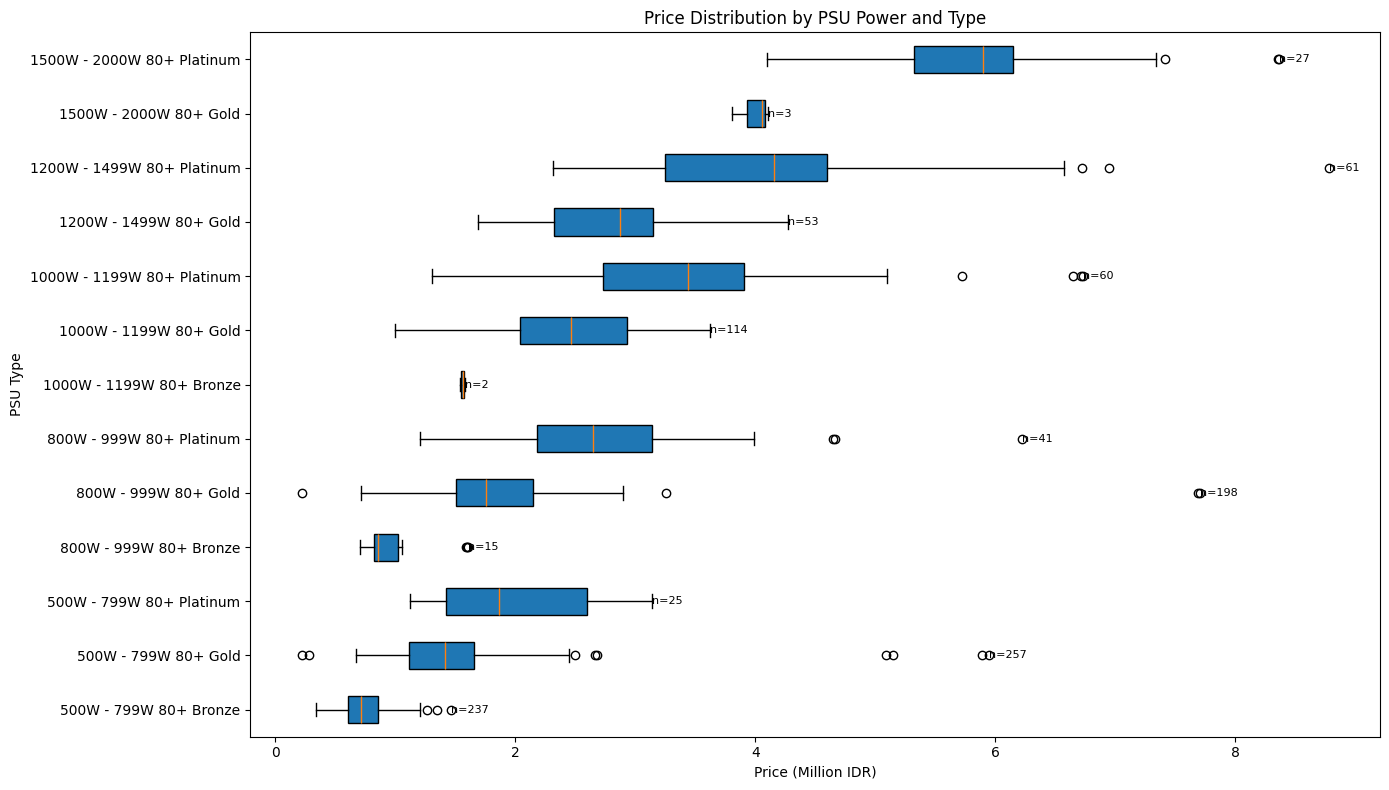

In [5]:
from collections import defaultdict
from price.shared import (
    ProductCategory, result_to_product_info, PSUInfo, PSUType, PSUPower
)

prods = load_all_data(date.today())[ProductCategory.PSU]

PSU_CATEGORIES = [
    "500W - 799W 80+ Bronze",
    "500W - 799W 80+ Gold",
    "500W - 799W 80+ Platinum",
    "800W - 999W 80+ Bronze",
    "800W - 999W 80+ Gold",
    "800W - 999W 80+ Platinum",
    "1000W - 1199W 80+ Bronze",
    "1000W - 1199W 80+ Gold",
    "1000W - 1199W 80+ Platinum",
    "1200W - 1499W 80+ Gold",
    "1200W - 1499W 80+ Platinum",
    "1500W - 2000W 80+ Gold",
    "1500W - 2000W 80+ Platinum",
]

prices_by_psu = defaultdict(list)
for x in prods:
    title = x.title + " " + (x.detail or "")
    info = result_to_product_info(title, ProductCategory.PSU, int(x.price))
    if info is None or not isinstance(info.details, PSUInfo):
        continue
    try:
        power_range = info.details.power_range
    except ValueError:
        continue
    label = f"{power_range.value} 80+ {info.details.psu_type.value}"
    if label in PSU_CATEGORIES:
        prices_by_psu[label].append(info.price)

labels = [c for c in PSU_CATEGORIES if c in prices_by_psu]
box_data = [[p / 1e6 for p in prices_by_psu[c]] for c in labels]

fig, ax = plt.subplots(figsize=(14, 8))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("PSU Type")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by PSU Power and Type")

for i, c in enumerate(labels):
    ax.annotate(
        f"n={len(prices_by_psu[c])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

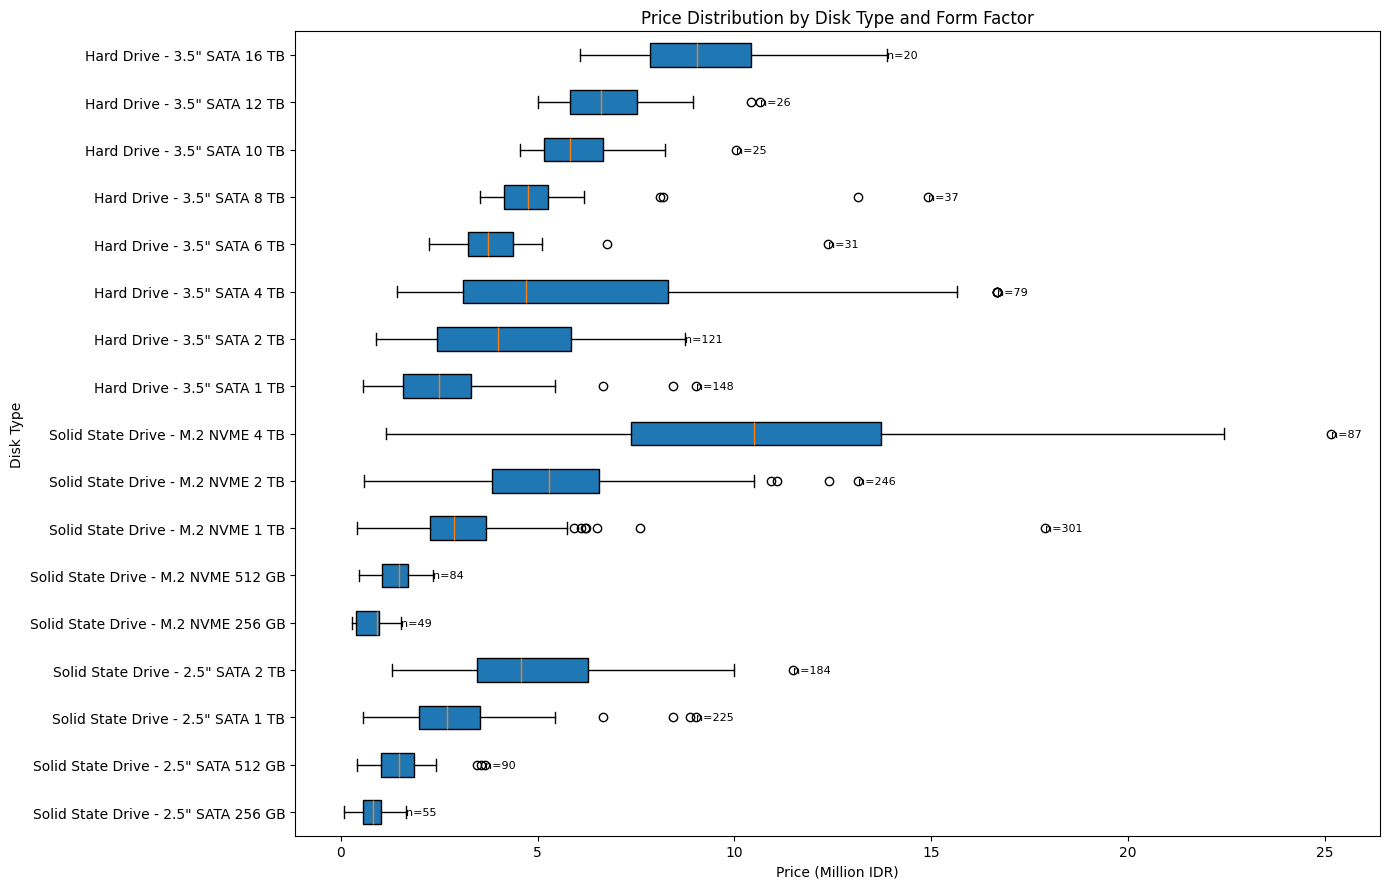

In [6]:
from collections import defaultdict
from price.shared import (
    ProductCategory, result_to_product_info, DiskInfo, DiskType, FormFactor
)

ssd_prods = load_all_data(date.today())[ProductCategory.SSD]
hdd_prods = load_all_data(date.today())[ProductCategory.HARDDISK]

def format_capacity(capacity_gb):
    if capacity_gb >= 1000:
        return f"{capacity_gb // 1000} TB"
    return f"{capacity_gb} GB"

DISK_TYPE_LABELS = {
    DiskType.SSD: "Solid State Drive",
    DiskType.HDD: "Hard Drive",
}

DISK_CATEGORIES = [
    'Solid State Drive - 2.5" SATA 256 GB',
    'Solid State Drive - 2.5" SATA 512 GB',
    'Solid State Drive - 2.5" SATA 1 TB',
    'Solid State Drive - 2.5" SATA 2 TB',
    "Solid State Drive - M.2 NVME 256 GB",
    "Solid State Drive - M.2 NVME 512 GB",
    "Solid State Drive - M.2 NVME 1 TB",
    "Solid State Drive - M.2 NVME 2 TB",
    "Solid State Drive - M.2 NVME 4 TB",
    'Hard Drive - 3.5" SATA 1 TB',
    'Hard Drive - 3.5" SATA 2 TB',
    'Hard Drive - 3.5" SATA 4 TB',
    'Hard Drive - 3.5" SATA 6 TB',
    'Hard Drive - 3.5" SATA 8 TB',
    'Hard Drive - 3.5" SATA 10 TB',
    'Hard Drive - 3.5" SATA 12 TB',
    'Hard Drive - 3.5" SATA 16 TB',
]

prices_by_disk = defaultdict(list)
for cat, prods in [(ProductCategory.SSD, ssd_prods), (ProductCategory.HARDDISK, hdd_prods)]:
    for x in prods:
        title = x.title + " " + (x.detail or "")
        info = result_to_product_info(title, cat, int(x.price))
        if info is None or not isinstance(info.details, DiskInfo):
            continue
        d = info.details
        type_label = DISK_TYPE_LABELS[d.disk_type]
        label = f"{type_label} - {d.form_factor.value} {format_capacity(d.capacity_gb)}"
        if label in DISK_CATEGORIES:
            prices_by_disk[label].append(info.price)

labels = [c for c in DISK_CATEGORIES if c in prices_by_disk]
box_data = [[p / 1e6 for p in prices_by_disk[c]] for c in labels]

fig, ax = plt.subplots(figsize=(14, 9))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("Disk Type")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by Disk Type and Form Factor")

for i, c in enumerate(labels):
    ax.annotate(
        f"n={len(prices_by_disk[c])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

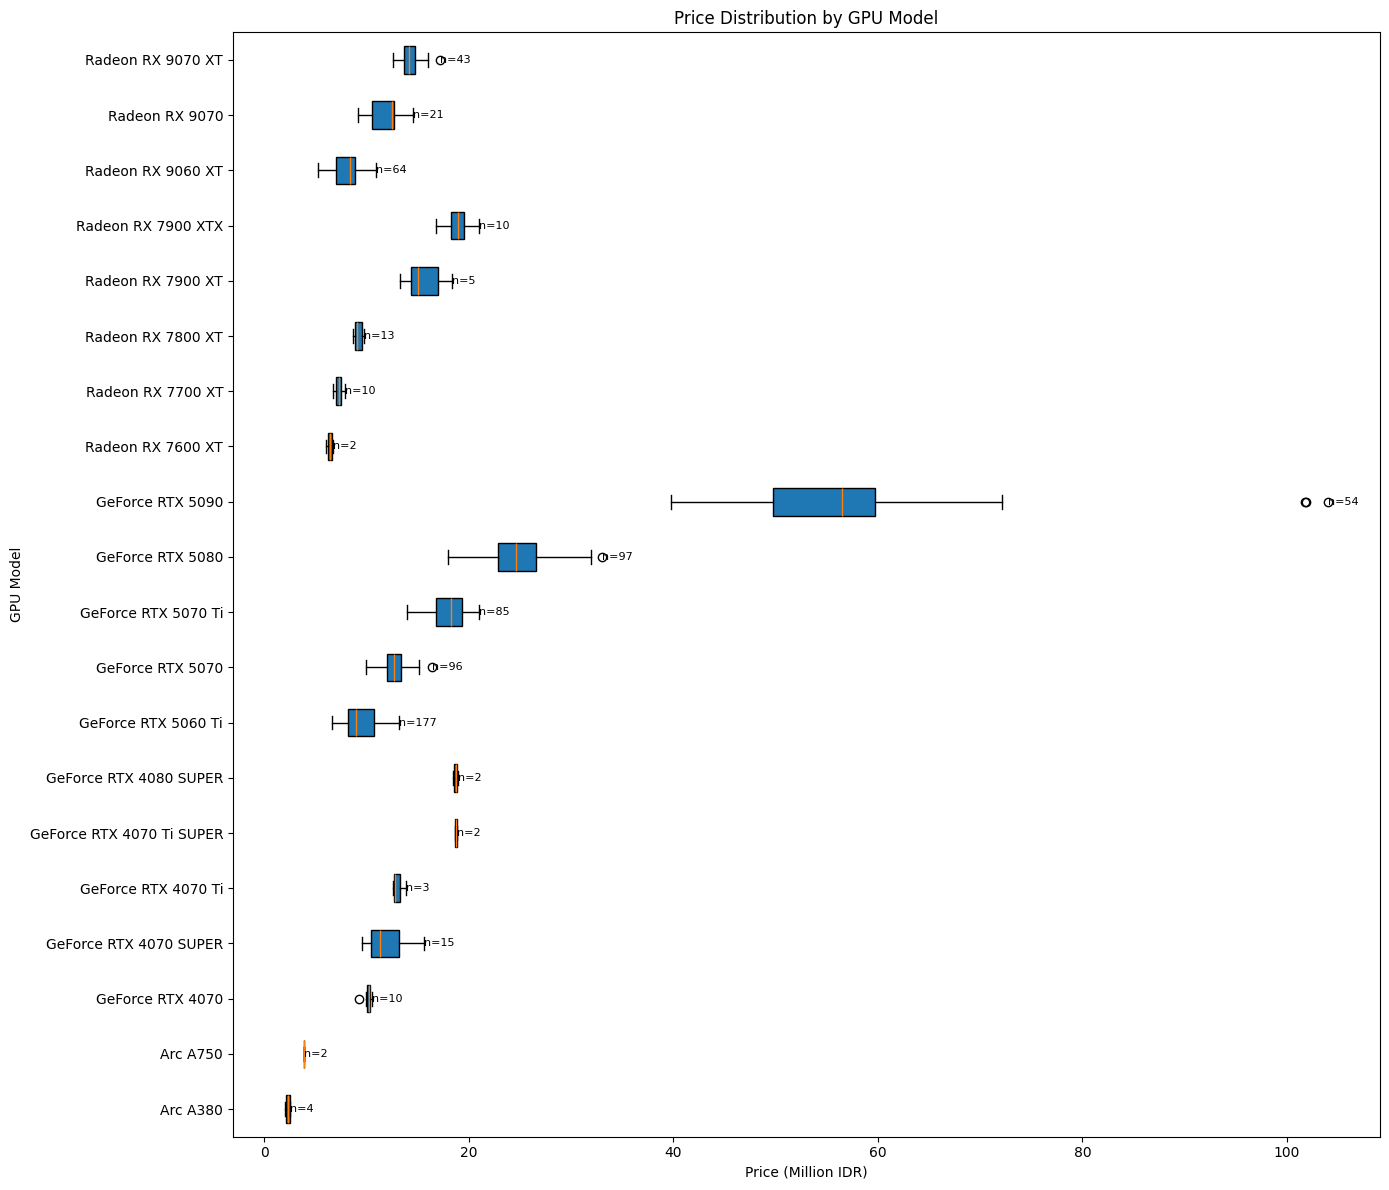

In [7]:
from collections import defaultdict
from price.shared import ProductCategory
import re

prods = load_all_data(date.today())[ProductCategory.VGA]

GPU_MODELS = [
    "GeForce RTX 4070 Ti SUPER",
    "GeForce RTX 4070 Ti",
    "GeForce RTX 4070 SUPER",
    "GeForce RTX 4070",
    "GeForce RTX 4080 SUPER",
    "GeForce RTX 4080",
    "GeForce RTX 4090",
    "GeForce RTX 5060 Ti",
    "GeForce RTX 5070 Ti",
    "GeForce RTX 5070",
    "GeForce RTX 5080",
    "GeForce RTX 5090",
    "Radeon RX 7600 XT",
    "Radeon RX 7700 XT",
    "Radeon RX 7800 XT",
    "Radeon RX 7900 XTX",
    "Radeon RX 7900 XT",
    "Radeon RX 9060 XT",
    "Radeon RX 9070 XT",
    "Radeon RX 9070",
    "Arc A770",
    "Arc A750",
    "Arc A380",
]

GPU_DISPLAY_ORDER = [
    "Arc A380",
    "Arc A750",
    "Arc A770",
    "GeForce RTX 4070",
    "GeForce RTX 4070 SUPER",
    "GeForce RTX 4070 Ti",
    "GeForce RTX 4070 Ti SUPER",
    "GeForce RTX 4080",
    "GeForce RTX 4080 SUPER",
    "GeForce RTX 4090",
    "GeForce RTX 5060 Ti",
    "GeForce RTX 5070",
    "GeForce RTX 5070 Ti",
    "GeForce RTX 5080",
    "GeForce RTX 5090",
    "Radeon RX 7600 XT",
    "Radeon RX 7700 XT",
    "Radeon RX 7800 XT",
    "Radeon RX 7900 XT",
    "Radeon RX 7900 XTX",
    "Radeon RX 9060 XT",
    "Radeon RX 9070",
    "Radeon RX 9070 XT",
]

def get_gpu_category(title):
    title_lower = title.lower()
    for model in GPU_MODELS:
        if model.lower() in title_lower:
            return model
    return None

prices_by_gpu = defaultdict(list)
for x in prods:
    title = x.title + " " + (x.detail or "")
    model = get_gpu_category(title)
    if model is None:
        continue
    prices_by_gpu[model].append(int(x.price))

labels = [c for c in GPU_DISPLAY_ORDER if c in prices_by_gpu]
box_data = [[p / 1e6 for p in prices_by_gpu[c]] for c in labels]

fig, ax = plt.subplots(figsize=(14, 12))
ax.boxplot(box_data, tick_labels=labels, vert=False, patch_artist=True)
ax.set_ylabel("GPU Model")
ax.set_xlabel("Price (Million IDR)")
ax.set_title("Price Distribution by GPU Model")

for i, c in enumerate(labels):
    ax.annotate(
        f"n={len(prices_by_gpu[c])}",
        xy=(max(box_data[i]), i + 1),
        ha="left",
        va="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()